In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import sys
import xarray as xr
import pandas as pd
sys.path.append('../../src/') # relative path to diusst/src folder

from diusst import Diusst

In [13]:
# Model settings
T_f = 300

kappa, mu, alpha = 1e-4, 1e-3, 3
sigma = 0.8

diffu_type = 'LIN'
wind_max = 10
CFL = 0.95

z_f = 10
dz0 = 0.1
ngrid = 40

In [15]:
# Atmospheric forcing functions
def ideal_atemp(times, Tmax=301, Tmin=299):
    return (Tmax+Tmin)/2 - (Tmax-Tmin)/2 * np.cos(2*np.pi*times/86400)

def ideal_wind(times, u0=2, uamp=1):
    return u0 + uamp/2 * np.cos(2*np.pi*times/86400)

def ideal_swrad(times, Rmax=1000):
    array = np.zeros(len(times))
    for i in range(len(times)):
        if np.cos(2*np.pi*times[i]/86400 + np.pi) > 0:
            array[i] = Rmax * np.cos(2*np.pi*times[i]/86400 + np.pi)
    return array

In [16]:
# Forcing timeseries (two days)
times = np.arange(0,2*86400,.5)
atemp = ideal_atemp(times,Tmax=T_f+1,Tmin=T_f-1)
winds = ideal_wind(times, u0=2, uamp=2)
swrad = ideal_swrad(times, Rmax=1000)
humid = np.ones(len(times))*15e-3

print("Number of time steps: {}".format(len(times)))

Number of time steps: 345600


In [17]:
# Store forcing timeseries as DataFrame
datastack = np.stack((times, atemp, winds, swrad, humid))
colnames = ['time','atemp_rel','wind','swrad','humid']
data = pd.DataFrame(datastack.transpose(),columns=colnames)

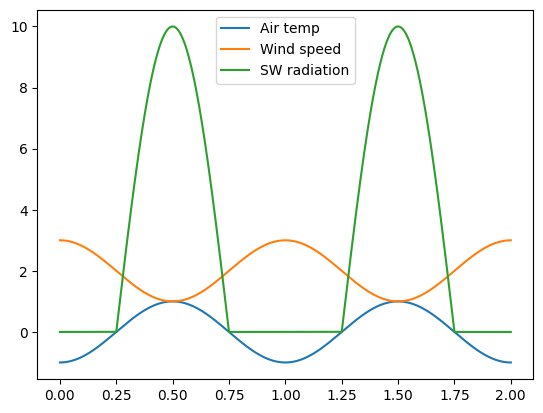

In [8]:
# Plot forcing timeseries
fig, ax = plt.subplots()
ax.plot(times/86400,atemp-T_f, label='Air temp')
ax.plot(times/86400,winds, label='Wind speed')
ax.plot(times/86400,swrad/100, label='SW radiation')
ax.legend()
plt.show()

In [9]:
# Parameter sweep - kappa
Akappas = [2e-5,5e-5,1e-4,2e-4,5e-4,1e-3]
Akappa = []
Akappamax = []
Akappashift = []
Akappaskin = []
for i in range(len(Akappas)):
    model_tmp = Diusst(T_f=T_f, kappa=Akappas[i], mu=mu, alpha=alpha, sigma=sigma,
                diffu_profile=diffu_type, CFL=CFL, z_f=z_f, dz0=dz0, ngrid=ngrid, reflect=True)
    sim_tmp = model_tmp.simulate(data, progress=False)
    Akappa.append(sim_tmp)
    Akappamax.append(np.amax(Akappa[i][0][:,0]-300))
    Akappashift.append(np.argmax(Akappa[i][0][:,0]-300)/len(Akappa[i][2])*48)
    Akappaskin.append(np.amin(Akappa[i][0][:,0]-300))
    print("{} done".format(i+1))

1 done
2 done
3 done
4 done
5 done
6 done


In [11]:
# Parameter sweep - mu
Amus = [1e-6,1e-5,1e-4,1e-3,1e-2,1e-1]
Amu = []
Amumax = []
Amushift=[]
Amuskin=[]
for i in range(len(Amus)):
    model_tmp = Diusst(T_f=T_f, kappa=kappa, mu=Amus[i], alpha=alpha, sigma=sigma,
                diffu_profile=diffu_type, CFL=CFL, z_f=z_f, dz0=dz0, ngrid=ngrid, reflect=True)
    sim_tmp = model_tmp.simulate(data, progress=False)
    Amu.append(sim_tmp)
    Amumax.append(np.amax(Amu[i][0][:,0]-300))
    Amushift.append(np.argmax(Amu[i][0][:,0]-300)/len(Amu[i][2])*48)
    Amuskin.append(np.amin(Amu[i][0][:,0]-300))
    print("{} done".format(i+1))

1 done
2 done
3 done
4 done
5 done
6 done


In [12]:
# Parameter sweep - alpha
Aalphas = [0.2,0.5,1,2,5,10]
Aalpha = []
Aalphamax = []
Aalphashift=[]
Aalphaskin=[]
for i in range(len(Aalphas)):
    model_tmp = Diusst(T_f=T_f, kappa=kappa, mu=mu, alpha=Aalphas[i], sigma=sigma,
                diffu_profile=diffu_type, CFL=CFL, z_f=z_f, dz0=dz0, ngrid=ngrid, reflect=True)
    sim_tmp = model_tmp.simulate(data, progress=False)
    Aalpha.append(sim_tmp)
    Aalphamax.append(np.amax(Aalpha[i][0][:,0]-300))
    Aalphashift.append(np.argmax(Aalpha[i][0][:,0]-300)/len(Aalpha[i][2])*48)
    Aalphaskin.append(np.amin(Aalpha[i][0][:,0]-300))
    print("{} done".format(i+1))

1 done
2 done
3 done
4 done
5 done
6 done


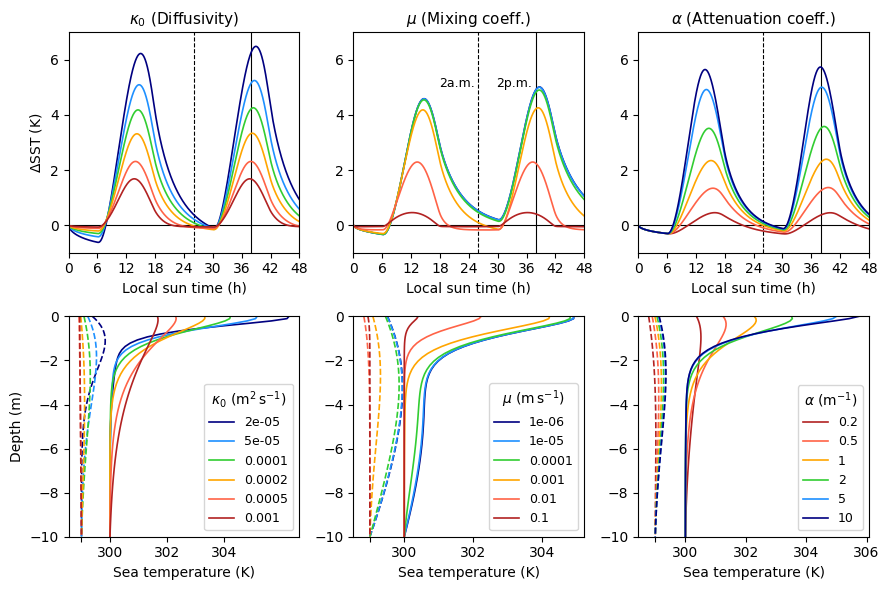

In [18]:
# Plot results

cols = ['navy','dodgerblue','limegreen','orange','tomato','firebrick']
lw=1.2
fig, ax = plt.subplots(2,3,figsize=(9,6))
for i in range(len(Akappas)):
    ax[0,0].plot(Akappa[i][1]/86400,Akappa[i][0][:,0]-300,c=cols[i], lw=lw)
    ax[0,1].plot(Amu[i][1]/86400,Amu[i][0][:,0]-300,c=cols[i], lw=lw)
    ax[0,2].plot(Aalpha[i][1]/86400,Aalpha[i][0][:,0]-300,c=cols[-i-1], lw=lw)
    
    noon = int(len(Akappa[i][1])/48)*(24+14)
    am2 = int(len(Akappa[i][1])/48)*26
    ax[1,0].plot(Akappa[i][0][noon]+1,Akappa[i][2],c=cols[i], lw=lw, label=str(Akappas[i]))
    ax[1,0].plot(Akappa[i][0][am2],Akappa[i][2],'--',c=cols[i], lw=lw)
    
    noon = int(len(Amu[i][1])/48)*(24+14)
    am2 = int(len(Amu[i][1])/48)*26
    ax[1,1].plot(Amu[i][0][noon]+1,Amu[i][2],c=cols[i], lw=lw, label=str(Amus[i]))
    ax[1,1].plot(Amu[i][0][am2],Amu[i][2],'--',c=cols[i], lw=lw)
    
    noon = int(len(Aalpha[i][1])/48)*(24+14)
    am2 = int(len(Aalpha[i][1])/48)*26
    ax[1,2].plot(Aalpha[i][0][noon]+1,Aalpha[i][2],c=cols[-i-1], lw=lw, label=str(Aalphas[i]))
    ax[1,2].plot(Aalpha[i][0][am2],Aalpha[i][2],'--',c=cols[-i-1], lw=lw)

ax[1,0].legend(fontsize=9,title=r'$\kappa_0$ (m$^2 \,$s$^{-1}$)')
ax[1,1].legend(fontsize=9,title=r'$\mu$ (m$\,$s$^{-1}$)')
ax[1,2].legend(fontsize=9,title=r'$\alpha$ (m$^{-1}$)')

titles=[r'$\kappa_0$ (Diffusivity)',r'$\mu$ (Mixing coeff.)',r'$\alpha$ (Attenuation coeff.)']
for i in range(3):
    ax[0,i].set(xlabel='Local sun time (h)',xticks=np.arange(0,2.25,0.25),xticklabels=np.arange(0,48+6,6))
    ax[1,i].set(xlabel='Sea temperature (K)')
    ax[0,i].set_title(titles[i],fontsize=11)
ax[0,0].set(ylabel=r'$\Delta$SST (K)')
ax[1,0].set(ylabel='Depth (m)')

for i in range(3):
    ax[0,i].axvline(x=(14+24)/24,c='k',zorder=0,lw=.8)
    ax[0,i].axvline(x=(2+24)/24,linestyle='--',c='k',zorder=0,lw=.8)
    ax[0,i].axhline(y=0,c='k',zorder=0,lw=.8)
    ax[0,i].set(ylim=(-1,7),xlim=(0,2))
    ax[1,i].set(ylim=(-10,0),xticks=[300,301,303,305],xticklabels=[None,'300','302','304'])
ax[1,2].set(ylim=(-10,0),xticks=[300,301,303,305,307],xticklabels=[None,'300','302','304','306'])
    
ax[0,1].text(1.05,5,'2a.m.',ha='right',fontsize=9)
ax[0,1].text(1.55,5,'2p.m.',ha='right',fontsize=9)

fig.tight_layout()

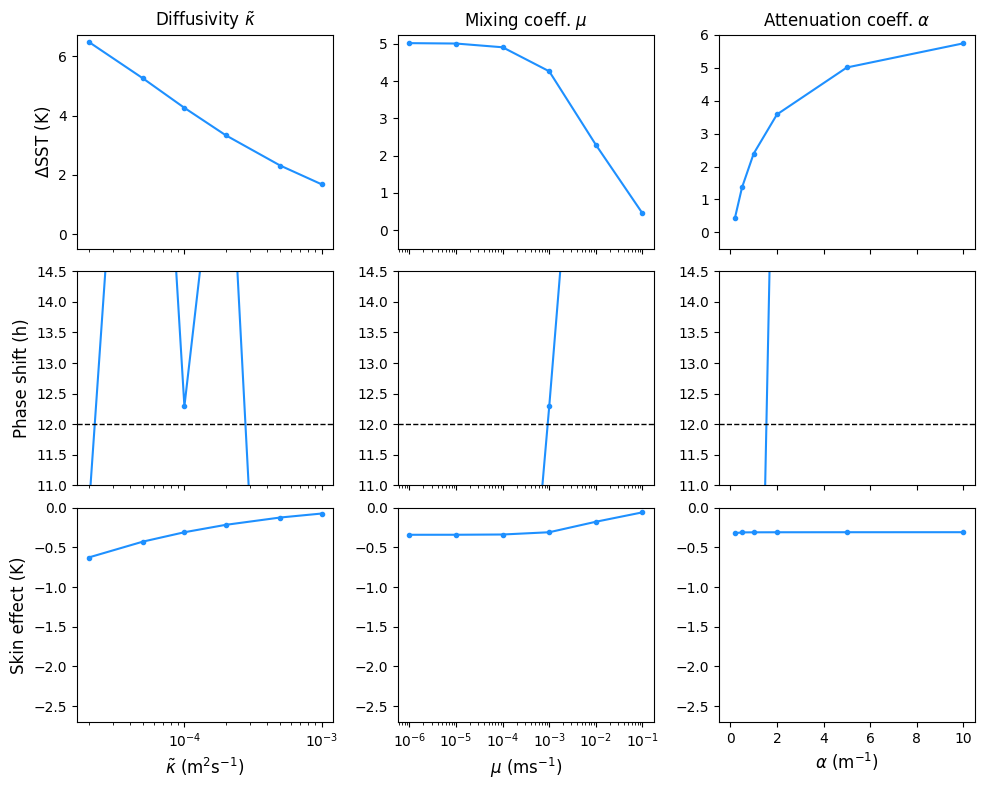

In [19]:
# Extra plot

fig, ax = plt.subplots(3,3,dpi=100,figsize=(10,8))
ax[0,0].semilogx(Akappas,Akappamax,'.-', c='dodgerblue')
ax[1,0].semilogx(Akappas,np.array(Akappashift)%24,'.-', c='dodgerblue')
ax[2,0].semilogx(Akappas,Akappaskin,'.-', c='dodgerblue')

ax[0,1].semilogx(Amus,Amumax,'.-', c='dodgerblue')
ax[1,1].semilogx(Amus,np.array(Amushift)%24,'.-', c='dodgerblue')
ax[2,1].semilogx(Amus,Amuskin,'.-', c='dodgerblue')

ax[0,2].plot(Aalphas,Aalphamax,'.-', c='dodgerblue')
ax[1,2].plot(np.array(Aalphas)[np.array(Aalphashift)>0],np.array(Aalphashift)[np.array(Aalphashift)>0]%24,'.-', c='dodgerblue')
ax[2,2].plot(Aalphas,Aalphaskin,'.-', c='dodgerblue')

titles=[r'Diffusivity $\tilde \kappa$',r'Mixing coeff. $\mu$',r'Attenuation coeff. $\alpha$']
xlabels=[r'$\tilde \kappa$ (m$^2$s$^{-1}$)',r'$\mu$ (ms$^{-1}$)',r'$\alpha$ (m$^{-1}$)']
ylabels=[r'$\Delta$SST (K)', 'Phase shift (h)', 'Skin effect (K)']
for i in range(3):
    ax[0,i].set_title(titles[i],fontsize=12)
    ax[2,i].set_xlabel(xlabels[i],fontsize=12)
    ax[i,0].set_ylabel(ylabels[i],fontsize=12)
    ax[0,i].set(ylim=(-0.5,None))
    ax[1,i].set(ylim=(11.,14.5))
    ax[1,i].axhline(y=12,lw=1,ls='--',c='k')
    ax[2,i].set(ylim=(-2.7,0))
    ax[0,i].set(xticklabels=[])
    ax[1,i].set(xticklabels=[])
    ax[i,2].set(xlim=(-0.5,10.5))

fig.tight_layout(h_pad=0.6)